In [1]:
import os
import zipfile
import numpy as np
import cv2
import matplotlib.pyplot as plt

from glob import glob
from skimage import io, color, measure, segmentation, morphology
from scipy import ndimage as ndi

In [9]:
def load_image_and_mask(image_id_path):
  img_path = glob(os.path.join(image_id_path, "images", "*"))[0]
  image = io.imread(img_path)

  mask_paths = glob(os.path.join(image_id_path, "masks", "*"))

  combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)

  for m in mask_paths:
    mask = io.imread(m)
    if mask.ndim == 3:
      mask = mask[..., 0]
    combined_mask = np.maximum(combined_mask, mask)

  return image, combined_mask

def preprocess(image):
  if image.ndim == 3:
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
  else:
    gray = image

  blur = cv2.GaussianBlur(gray, (5,5), 0)

  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(blur)

  _, binary = cv2.threshold(
    clahe, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
  )

  # POLARITY FIX 
  if np.mean(binary == 255) > 0.5:
    binary = 255 - binary

  # MASK CLEANUP 
  kernel = np.ones((3,3), np.uint8)
  binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
  binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

  return gray, binary

def get_distance(binary):
    return cv2.distanceTransform(binary, cv2.DIST_L2, 5)


In [ ]:
def preprocess_for_watershed(gray):
    kernel = np.ones((3,3), np.uint8)

    gray = cv2.GaussianBlur(gray, (5,5), 0)

    _, binary = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Ensure nuclei are white (critical for DT + watershed)
    if np.mean(binary == 255) > 0.5:
        binary = 255 - binary

    # Remove noise + fill holes
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

    return binary

In [10]:
from skimage import measure, segmentation

def naive_watershed(gray, binary):
  kernel = np.ones((3,3), np.uint8)

  gray_blur = cv2.GaussianBlur(gray, (3,3), 0)

  gradient = cv2.morphologyEx(
    gray_blur,
    cv2.MORPH_GRADIENT,
    kernel
  )

  markers = measure.label(binary > 0)

  labels = segmentation.watershed(
    gradient,
    markers,
    mask=(binary > 0)
  )

  return labels

def marker_watershed(gray, binary):
  kernel = np.ones((3,3), np.uint8)

  # Sure background
  sure_bg = cv2.dilate(binary, kernel, iterations=3)

  # Distance transform (expects white foreground)
  dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)

  # Marker threshold (tunable)
  thresh_val = 0.35 * dist.max()
  _, sure_fg = cv2.threshold(dist, thresh_val, 255, 0)

  sure_fg = np.uint8(sure_fg)

  # Unknown region
  unknown = cv2.subtract(sure_bg, sure_fg)

  # Label markers
  markers = measure.label(sure_fg > 0)

  # Force unknown = 0 (important)
  markers[unknown == 255] = 0

  # Smooth gradient → reduces noisy boundaries
  gray_blur = cv2.GaussianBlur(gray, (3,3), 0)

  gradient = cv2.morphologyEx(
    gray_blur,
    cv2.MORPH_GRADIENT,
    kernel
  )

  labels = segmentation.watershed(
    gradient,
    markers,
    mask=(binary > 0)
  )

  return labels


In [6]:
def remove_small(labels, min_size=30):
    return morphology.remove_small_objects(labels.astype(int), min_size)
def dice(gt, pred):
    gt = gt > 0
    pred = pred > 0
    return 2*np.sum(gt & pred) / (np.sum(gt) + np.sum(pred) + 1e-8)
def iou(gt, pred):
    gt = gt > 0
    pred = pred > 0
    union = np.sum(gt | pred)
    if union == 0:
        return 1.0
    return np.sum(gt & pred) / union
def count_instances(mask):
    return len(np.unique(mask)) - 1
def overlay(image, labels):
    return color.label2rgb(labels, image=image, bg_label=0)


C:\Users\ROG\AppData\Local\Temp\ipykernel_10008\4266654721.py:2: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  return morphology.remove_small_objects(labels.astype(int), min_size)


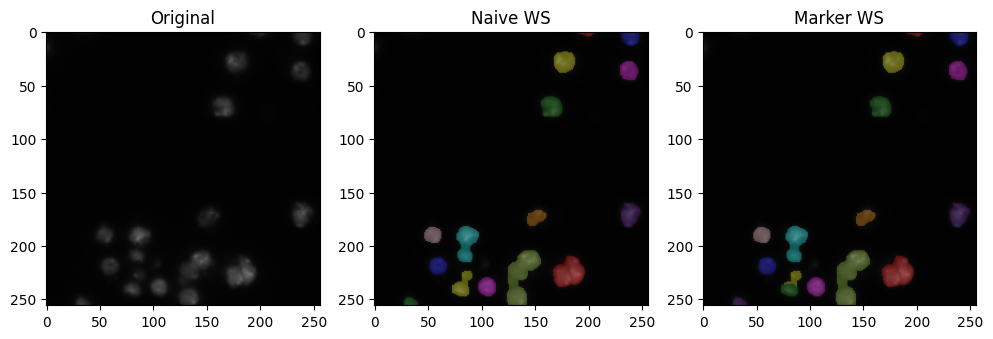

C:\Users\ROG\AppData\Local\Temp\ipykernel_10008\4266654721.py:2: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  return morphology.remove_small_objects(labels.astype(int), min_size)


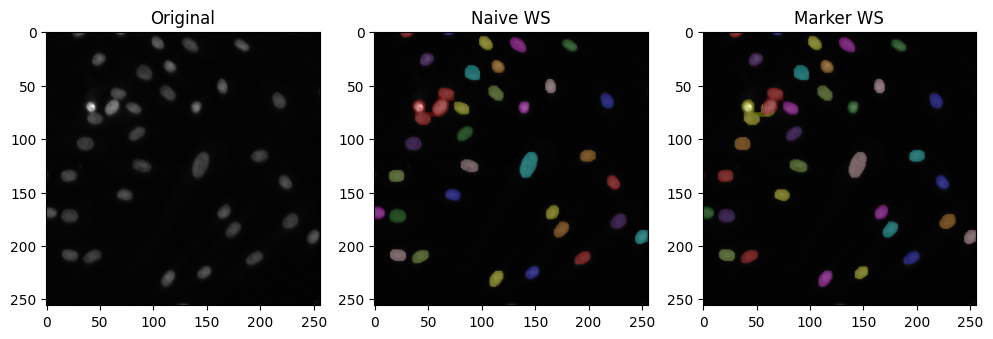

C:\Users\ROG\AppData\Local\Temp\ipykernel_10008\4266654721.py:2: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  return morphology.remove_small_objects(labels.astype(int), min_size)


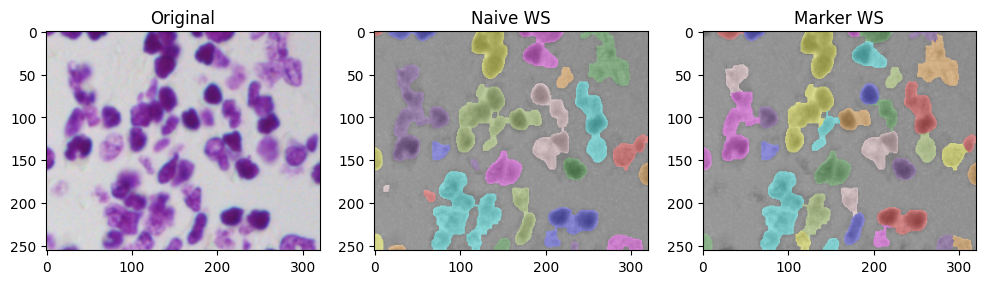

C:\Users\ROG\AppData\Local\Temp\ipykernel_10008\4266654721.py:2: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  return morphology.remove_small_objects(labels.astype(int), min_size)


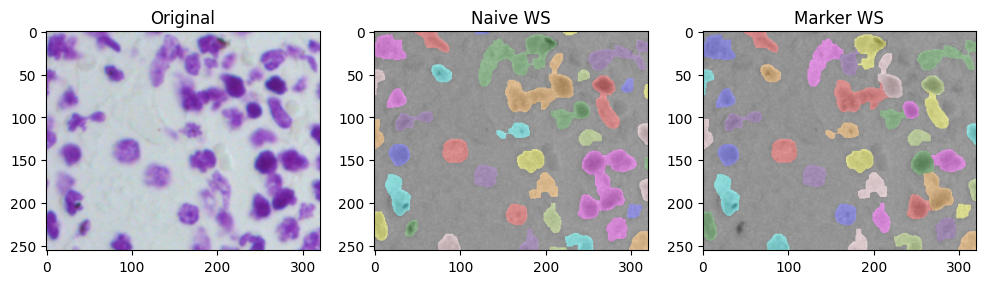

C:\Users\ROG\AppData\Local\Temp\ipykernel_10008\4266654721.py:2: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  return morphology.remove_small_objects(labels.astype(int), min_size)


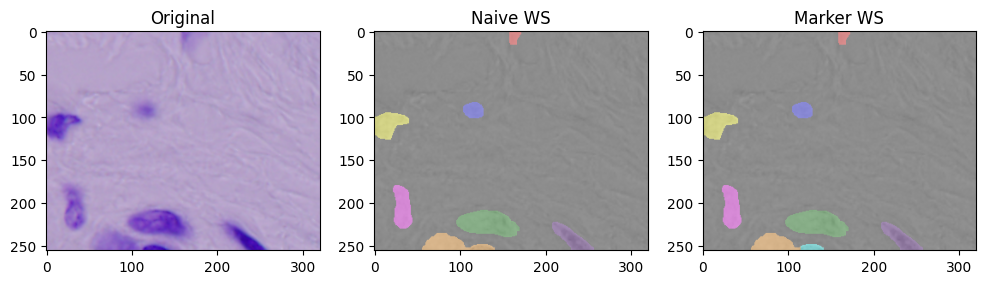

===== AVERAGE PERFORMANCE =====
Mean Dice (Naive) : 0.8651043730598301
Mean Dice (Marker): 0.8629835673957521
Mean IoU (Naive)  : 0.7676839083081155
Mean IoU (Marker) : 0.7645526721871733


In [12]:
TRAIN_PATH = r'C:\V\sem_6_notes\DL_MedicalImage_processing\CellNucleiSeparation\Data\stage1_train'
ids = os.listdir(TRAIN_PATH)[:5]

dice_naive_scores = []
dice_marker_scores = []

iou_naive_scores = []
iou_marker_scores = []

for image_id in ids:

    path = os.path.join(TRAIN_PATH, image_id)

    image, gt_mask = load_image_and_mask(path)

    gray, binary = preprocess(image)

    naive = naive_watershed(gray, binary)
    marker = marker_watershed(gray, binary)

    naive = remove_small(naive)
    marker = remove_small(marker)

    # Compute metrics
    d_naive = dice(gt_mask, naive)
    d_marker = dice(gt_mask, marker)

    i_naive = iou(gt_mask, naive)
    i_marker = iou(gt_mask, marker)

    dice_naive_scores.append(d_naive)
    dice_marker_scores.append(d_marker)

    iou_naive_scores.append(i_naive)
    iou_marker_scores.append(i_marker)

    # Optional visualization
    plt.figure(figsize=(12,6))

    plt.subplot(1,3,1)
    plt.imshow(image[:, :, :3])
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.imshow(overlay(image[:, :, :3], naive))
    plt.title("Naive WS")

    plt.subplot(1,3,3)
    plt.imshow(overlay(image[:, :, :3], marker))
    plt.title("Marker WS")

    plt.show()

#Final averages
print("===== AVERAGE PERFORMANCE =====")
print("Mean Dice (Naive) :", np.mean(dice_naive_scores))
print("Mean Dice (Marker):", np.mean(dice_marker_scores))

print("Mean IoU (Naive)  :", np.mean(iou_naive_scores))
print("Mean IoU (Marker) :", np.mean(iou_marker_scores))